In [197]:
import pandas as pd
import numpy as np
orders=pd.read_csv('orders.csv')
costs=pd.read_csv('costs.csv')
visits=pd.read_csv('visits.csv')

## Проверка на дубликаты

In [200]:
# Проверка на полные дубликаты
duplicate_rows = orders[orders.duplicated()]

# Количество полных дублей
num_duplicates = duplicate_rows.shape[0]

print(f'Найдено полных дубликатов: {num_duplicates}')

duplicate_rows = costs[costs.duplicated()]

# Количество полных дублей
num_duplicates = duplicate_rows.shape[0]

print(f'Найдено полных дубликатов: {num_duplicates}')

duplicate_rows = visits[visits.duplicated()]

# Количество полных дублей
num_duplicates = duplicate_rows.shape[0]

print(f'Найдено полных дубликатов: {num_duplicates}')


Найдено полных дубликатов: 0
Найдено полных дубликатов: 0
Найдено полных дубликатов: 0


## Период наблюдений

In [203]:
# Проверка периодов событий
print('Session End min date', visits['Session End'].min())
print('Session End max date', visits['Session End'].max())
print('Event Dt min date', orders['Event Dt'].min())
print('Event Dt max date', orders['Event Dt'].max())
print('costs Dt min date', costs['dt'].min())
print('costs Dt max date', costs['dt'].max())

Session End min date 2019-05-01 00:07:06
Session End max date 2019-11-01 01:38:46
Event Dt min date 2019-05-01 00:28:11
Event Dt max date 2019-10-31 23:56:56
costs Dt min date 2019-05-01
costs Dt max date 2019-10-27


## Сезонность?

In [206]:
# Подсчет покупок по месяцам
# Убедимся, что 'Event Dt' в формате datetime
orders['Event Dt'] = pd.to_datetime(orders['Event Dt'])

# Группировка по месяцу
monthly_counts = orders.groupby(orders['Event Dt'].dt.to_period('M')).size().reset_index(name='count')
print(monthly_counts)

  Event Dt  count
0  2019-05   2962
1  2019-06   4875
2  2019-07   6556
3  2019-08   7582
4  2019-09   8430
5  2019-10   9807


## Первичная покупка клиентом

In [209]:
# Оставляем только первые покупки у клиентов
# Преобразуем поле purchase_date в формат datetime (если еще не преобразовано)
orders['Event Dt'] = pd.to_datetime(orders['Event Dt'])

# Сортируем по customer_id и purchase_date, чтобы первая покупка была в начале
orders_sorted = orders.sort_values(by=['User Id', 'Event Dt'])

# Оставляем только первую покупку для каждого клиента
first_purchases = orders_sorted.groupby('User Id').first().reset_index()

In [211]:
# Подсчет покупок по месяцам, только первые покупки
# Убедимся, что 'Event Dt' в формате datetime
first_purchases['Event Dt'] = pd.to_datetime(first_purchases['Event Dt'])

# Группировка по месяцу
monthly_counts = first_purchases.groupby(first_purchases['Event Dt'].dt.to_period('M')).size().reset_index(name='count')
print(monthly_counts)

  Event Dt  count
0  2019-05   1226
1  2019-06   1416
2  2019-07   1429
3  2019-08   1571
4  2019-09   1651
5  2019-10   1588


## Объединяем первые покупки с таблицей visits

In [214]:

# Шаг 1: джоин по User Id (многие ко многим)
merged_first_purchases = pd.merge(visits, first_purchases, on='User Id', how='left')

# Шаг 2: атрибут визитов до первой покупки по условию даты — только те заказы, что были после или во время визита
merged_first_purchases['is_paid'] = merged_first_purchases['Event Dt'] >= merged_first_purchases['Session Start'] 

# Шаг 3: атрибут визитов не купивших клиентов
merged_first_purchases['is_false'] = merged_first_purchases['Event Dt'].isna()

# Шаг 4: атрибут визитов первой покупки или клиентов, которые не купили
merged_first_purchases['is_valid'] = (merged_first_purchases['is_paid']==True)|(merged_first_purchases['is_false']==True)

merged_first_purchases_final = merged_first_purchases[merged_first_purchases['is_valid']==True]

## Создаём нумерацию повторений канала по каждому StudentID

In [216]:

merged_first_purchases_final['Channel Count'] = merged_first_purchases_final.groupby(['User Id', 'Channel']).cumcount() + 1
    
    # Формируем Channel с номером, если он не первый
merged_first_purchases_final['Channel Numbered'] = merged_first_purchases_final.apply(
        lambda row: f"{row['Channel']} {row['Channel Count']}" if row['Channel Count'] > 1 else f"{row['Channel']} 1",
        axis=1
    )

/var/folders/_z/bhy5vwy90pzd9s4jngc90jzr0000gn/T/ipykernel_17436/98503601.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_first_purchases_final['Channel Count'] = merged_first_purchases_final.groupby(['User Id', 'Channel']).cumcount() + 1
/var/folders/_z/bhy5vwy90pzd9s4jngc90jzr0000gn/T/ipykernel_17436/98503601.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_first_purchases_final['Channel Numbered'] = merged_first_purchases_final.apply(


## Добавляем атрибуцию first last click

In [218]:
# 1. Считаем min и max Session Start по каждому пользователю
min_max_sessions = merged_first_purchases_final.groupby('User Id')['Session Start'].agg(
    Min_Session_Start='min',
    Max_Session_Start='max'
).reset_index()

# 2. Присоединяем Channel, соответствующий минимальной дате
min_channels = pd.merge(
    merged_first_purchases_final,
    min_max_sessions[['User Id', 'Min_Session_Start']],
    left_on=['User Id', 'Session Start'],
    right_on=['User Id', 'Min_Session_Start'],
    how='inner'
)[['User Id', 'Min_Session_Start', 'Channel']]
min_channels.rename(columns={'Channel': 'Min_Channel'}, inplace=True)

# 3. Присоединяем Channel, соответствующий максимальной дате
max_channels = pd.merge(
    merged_first_purchases_final,
    min_max_sessions[['User Id', 'Max_Session_Start']],
    left_on=['User Id', 'Session Start'],
    right_on=['User Id', 'Max_Session_Start'],
    how='inner'
)[['User Id', 'Max_Session_Start', 'Channel']]
max_channels.rename(columns={'Channel': 'Max_Channel'}, inplace=True)

# 4. Объединяем всё в один финальный датафрейм
final = min_max_sessions \
    .merge(min_channels, on=['User Id', 'Min_Session_Start'], how='left') \
    .merge(max_channels, on=['User Id', 'Max_Session_Start'], how='left')

merged_first_purchases_final= pd.merge(merged_first_purchases_final, final, on='User Id', how='inner')

## Добавляем атрибуцию про путь клиента

In [219]:
import pandas as pd


# 1. Сортировка по времени сессии для правильной цепочки касаний
visits_orders_sorted = merged_first_purchases_final[merged_first_purchases_final['is_valid']==True].sort_values(by=['User Id', 'Session Start'])


# 2. Группировка для создания цепочки касаний
def build_touch_path(group):
    channels = group['Channel Numbered'].tolist()
    if group['is_paid'].all():
        channels.append('Conversion')  # дополняем  элемент  Conversion, если была покупка
    return ' > '.join(channels)

# 3. Кол-во касаний
def num_touches(group):
    return group.shape[0]

def min_channel(group):
    channels = group['Min_Channel'].tolist()
    first_channel = channels[0]
    return first_channel
    
def is_paid(group):
    channels = group['is_paid'].tolist()
    first_channel = channels[0]
    return first_channel

def live_time(group):
    min_session = group['Min_Session_Start'].tolist()
    if group['is_paid'].all():
        max_session = group['Event Dt'].tolist()
    else:
        max_session = group['Max_Session_Start'].tolist()
    first_channel = round((pd.to_datetime(max_session[0])- pd.to_datetime(min_session[0])).total_seconds()/3600,1)
    return first_channel
    

# 8. Построим финальный датафрейм
final_df = visits_orders_sorted.groupby('User Id').apply(lambda group: pd.Series({
    'touch_path': build_touch_path(group),
    'num_touches': num_touches(group),
    'Min_Channel': min_channel(group),
    'is_paid': is_paid(group),
    'live_time_hours': live_time(group)
    
})).reset_index()


## Расчитыввам средний путь до покупки по каналам привлечения

In [33]:
# Группировка и агрегация
live_time_stats = final_df.groupby(['is_paid', 'Min_Channel'])['live_time_hours'].agg(
    max_live_time='max',
    min_live_time='min',
    mean_live_time='mean',
    median_live_time='median'
).reset_index()

live_time_stats['mean_live_time'] = live_time_stats['mean_live_time'].round(1)
live_time_stats['median_live_time'] = live_time_stats['median_live_time'].round(1)

# Вывод результата
print(live_time_stats)

    is_paid         Min_Channel  max_live_time  min_live_time  mean_live_time  \
0     False          AdNonSense         3146.4            0.0            71.1   
1     False            FaceBoom         3960.1            0.0            70.9   
2     False             LeapBob         3749.6            0.0            71.9   
3     False        MediaTornado         3958.3            0.0            72.0   
4     False  OppleCreativeMedia         3610.9            0.0            73.1   
5     False      RocketSuperAds         3253.2            0.0            71.8   
6     False              TipTop         4135.3            0.0            70.6   
7     False      WahooNetBanner         3239.0            0.0            70.3   
8     False             YRabbit         3036.4            0.0            68.1   
9     False      lambdaMediaAds         3158.1            0.0            79.8   
10    False             organic         3782.9            0.0            74.8   
11     True          AdNonSe

In [311]:
def trimmed_mean(group):
    # Расчёт границ перцентилей
    lower = group['live_time_hours'].quantile(0.05)
    upper = group['live_time_hours'].quantile(0.95)
    
    # Отфильтровываем выбросы
    trimmed = group[(group['live_time_hours'] >= lower) & (group['live_time_hours'] <= upper)]
    
    # Возвращаем среднее без выбросов
    return trimmed['live_time_hours'].mean()

# Применяем к каждой группе
trimmed_mean_df = final_df.groupby(['is_paid', 'Min_Channel']).apply(trimmed_mean).reset_index(name='trimmed_mean_live_time')

# Округляем при необходимости
trimmed_mean_df['trimmed_mean_live_time'] = trimmed_mean_df['trimmed_mean_live_time'].round(1)
trimmed_mean_df = trimmed_mean_df[['Min_Channel', 'trimmed_mean_live_time']][trimmed_mean_df['is_paid']==True]
trimmed_mean_df.rename(columns={'Min_Channel': 'Channel'}, inplace=True)
# Результат
print(trimmed_mean_df)
# Объединяем данные с основным df
merged_first_purchases_final= pd.merge(merged_first_purchases_final, trimmed_mean_df, on='Channel', how='inner')

merged_first_purchases_final= pd.merge(merged_first_purchases_final,
                                       final_df[['User Id','touch_path', 'num_touches' ,'live_time_hours']], on='User Id', how='inner') 


               Channel  trimmed_mean_live_time
11          AdNonSense                    13.5
12            FaceBoom                     7.5
13             LeapBob                    32.2
14        MediaTornado                    30.7
15  OppleCreativeMedia                    25.3
16      RocketSuperAds                    55.2
17              TipTop                    31.7
18      WahooNetBanner                    28.8
19             YRabbit                    23.8
20      lambdaMediaAds                    28.5
21             organic                    34.9


## Добавляем атрибуцию про путь клиента

In [230]:

# Убедимся, что даты в нужном формате
merged_first_purchases_final['Session Start'] = pd.to_datetime(merged_first_purchases_final['Session Start'])
merged_first_purchases_final['Session End'] = pd.to_datetime(merged_first_purchases_final['Session End'])

# Сортировка по пользователю и времени
merged_first_purchases_final = merged_first_purchases_final.sort_values(by=['User Id', 'Session Start'])

# 1. Группировка по пользователям
grouped = merged_first_purchases_final.groupby('User Id')

# 2. Следующий визит
merged_first_purchases_final['Next Session Start'] = grouped['Session Start'].shift(-1)

# 3. Время между визитами
merged_first_purchases_final['Time Between Visits'] = merged_first_purchases_final['Next Session Start'] - merged_first_purchases_final['Session Start']
merged_first_purchases_final['Time Between Visits'] = merged_first_purchases_final['Time Between Visits'].dt.total_seconds() // 3600

# 4  Убедимся, что датафрейм отсортирован корректно
merged_first_purchases_final = merged_first_purchases_final.sort_values(by=['User Id', 'Session Start'])

# Накопительное время между визитами по каждому пользователю
merged_first_purchases_final['Cumulative Time Between Visits'] = (
    merged_first_purchases_final
    .groupby('User Id')['Time Between Visits']
    .cumsum()
)



# 5. Заполняем NaN значением live_time_hours
merged_first_purchases_final['Time Between Visits'] = merged_first_purchases_final['Time Between Visits'].fillna(
    merged_first_purchases_final['live_time_hours']
)

merged_first_purchases_final['Cumulative Time Between Visits'] = merged_first_purchases_final['Cumulative Time Between Visits'].fillna(
    merged_first_purchases_final['live_time_hours']
)




## Алгоритм расчета first click plus

In [234]:
# first click plus
def get_min_channel_mean_live_time(group):
    # Сортировка по Channel Count
    group_sorted = group.sort_values(by='Channel Count')

    # Ищем первую строку, где trimmed_mean_live_time > Time Between Visits
    condition = group_sorted['trimmed_mean_live_time'] > group_sorted['Time Between Visits']
    match = group_sorted[condition]

    if not match.empty:
        # Если нашлось — берём Channel из первой подходящей строки
        return match.iloc[0]['Channel']
    else:
        # Иначе — берём Channel из последней строки
        return group_sorted.iloc[-1]['Channel']

# Применяем к каждому пользователю
min_channel_mean_live_time_series = merged_first_purchases_final.groupby('User Id').apply(get_min_channel_mean_live_time)

# Преобразуем в DataFrame
min_channel_mean_live_time_df = min_channel_mean_live_time_series.reset_index()
min_channel_mean_live_time_df.columns = ['User Id', 'Min_Channel_mean_live_time']

# Объединяем обратно с основной таблицей
merged_first_purchases_final = merged_first_purchases_final.merge(min_channel_mean_live_time_df, on='User Id', how='left')


In [258]:
# дата first click plus
def get_min_date_mean_live_time(group):
    # Сортировка по Channel Count
    group_sorted = group.sort_values(by='Channel Count')

    # Ищем первую строку, где trimmed_mean_live_time > Time Between Visits
    condition = group_sorted['trimmed_mean_live_time'] > group_sorted['Time Between Visits']
    match = group_sorted[condition]

    if not match.empty:
        # Если нашлось — берём Channel из первой подходящей строки
        return match.iloc[0]['Session Start']
    else:
        # Иначе — берём Channel из последней строки
        return group_sorted.iloc[-1]['Session Start']

# Применяем к каждому пользователю
min_channel_mean_live_time_series = merged_first_purchases_final.groupby('User Id').apply(get_min_date_mean_live_time)

# Преобразуем в DataFrame
min_date_mean_live_time_df = min_channel_mean_live_time_series.reset_index()
min_date_mean_live_time_df.columns = ['User Id', 'Min_Session_mean_live_time']

# Объединяем обратно с основной таблицей
merged_first_purchases_final = merged_first_purchases_final.merge(min_date_mean_live_time_df, on='User Id', how='left')


## Выгрузка датасета для проверки мультиканальной модели

In [250]:
grouped_df = merged_first_purchases_final.groupby(
    ['User Id', 'Min_Channel_mean_live_time', 'Min_Channel', 'Max_Channel', 'touch_path', 'is_paid'],
    as_index=False
).size() 

In [256]:
grouped_df.to_csv('grouped_users.csv', index=False)

## Собираем датасет для сравнения метрик конверсии/ доходности по различным кликами

In [270]:

# 2. Группируем по Channel + Min Session Start
merged_first_purchases_final['Min Session M'] = pd.to_datetime(merged_first_purchases_final['Min_Session_Start']).dt.to_period('M').dt.to_timestamp()
merged_first_purchases_final['Min Session M'] = merged_first_purchases_final['Min Session M'].dt.strftime('%Y-%m-%d')

merged_first_purchases_final['Max Session M'] = pd.to_datetime(merged_first_purchases_final['Max_Session_Start']).dt.to_period('M').dt.to_timestamp()
merged_first_purchases_final['Max Session M'] = merged_first_purchases_final['Max Session M'].dt.strftime('%Y-%m-%d')

merged_first_purchases_final['Min Session plus M'] = pd.to_datetime(merged_first_purchases_final['Min_Session_mean_live_time']).dt.to_period('M').dt.to_timestamp()
merged_first_purchases_final['Min Session plus M'] = merged_first_purchases_final['Min Session plus M'].dt.strftime('%Y-%m-%d')

costs['Min Session M'] = pd.to_datetime(costs['dt']).dt.to_period('M').dt.to_timestamp()
costs['Min Session M'] = costs['Min Session M'].dt.strftime('%Y-%m-%d')

total = merged_first_purchases_final.groupby(['Channel', 'Min Session M'])['User Id'].nunique().reset_index(name='total_users')
paid = merged_first_purchases_final[merged_first_purchases_final['is_paid'] == True].groupby(['Channel', 'Min Session M'])['User Id'].nunique().reset_index(name='paid_users')
unpaid = merged_first_purchases_final[merged_first_purchases_final['is_false'] == True].groupby(['Channel', 'Min Session M'])['User Id'].nunique().reset_index(name='unpaid_users')


total_last = merged_first_purchases_final.groupby(['Channel', 'Max Session M'])['User Id'].nunique().reset_index(name='total_users_last')
total_last.rename(columns={'Max Session M': 'Min Session M'}, inplace=True)
paid_last = merged_first_purchases_final[merged_first_purchases_final['is_paid'] == True].groupby(['Channel', 'Max Session M'])['User Id'].nunique().reset_index(name='paid_users_last')
paid_last.rename(columns={'Max Session M': 'Min Session M'}, inplace=True)



total_plus = merged_first_purchases_final.groupby(['Min_Channel_mean_live_time', 'Min Session plus M'])['User Id'].nunique().reset_index(name='total_users_plus')
total_plus.rename(columns={'Min Session plus M': 'Min Session M', 'Min_Channel_mean_live_time': 'Channel'}, inplace=True)

paid_plus = merged_first_purchases_final[merged_first_purchases_final['is_paid'] == True].groupby(['Min_Channel_mean_live_time', 'Min Session plus M'])['User Id'].nunique().reset_index(name='paid_users_plus')
paid_plus.rename(columns={'Min Session plus M': 'Min Session M', 'Min_Channel_mean_live_time': 'Channel'}, inplace=True)



revenue_first = merged_first_purchases_final[
    merged_first_purchases_final['Revenue'].notna()
][['User Id', 'Min_Channel', 'Min Session M', 'Revenue']].drop_duplicates()
revenue_first= revenue_first.groupby(['Min_Channel', 'Min Session M'])['Revenue'].sum().reset_index()
revenue_first.rename(columns={'Min_Channel': 'Channel', 'Revenue': 'First click Revenue'}, inplace=True)



revenue_last = merged_first_purchases_final[
    merged_first_purchases_final['Revenue'].notna()
][['User Id', 'Max_Channel', 'Max Session M', 'Revenue']].drop_duplicates()
revenue_last= revenue_last.groupby(['Max_Channel', 'Max Session M'])['Revenue'].sum().reset_index()
revenue_last.rename(columns={'Max_Channel': 'Channel', 'Max Session M': 'Min Session M', 'Revenue': 'Last click Revenue'}, inplace=True)


revenue_first_plus = merged_first_purchases_final[
    merged_first_purchases_final['Revenue'].notna()
][['User Id', 'Min_Channel_mean_live_time', 'Min Session plus M', 'Revenue']].drop_duplicates()
revenue_first_plus= revenue_first_plus.groupby(['Min_Channel_mean_live_time', 'Min Session plus M'])['Revenue'].sum().reset_index()
revenue_first_plus.rename(columns={'Min Session plus M': 'Min Session M', 'Min_Channel_mean_live_time': 'Channel', 'Revenue': 'First click plus Revenue'}, inplace=True)



costs_sum = costs.groupby(['Min Session M', 'Channel'])['costs'].sum().reset_index()

# 5. Объединяем в одну таблицу
merged = total.merge(paid, on=['Channel', 'Min Session M'], how='left') \
              .merge(unpaid, on=['Channel', 'Min Session M'], how='left')\
              .merge(revenue_first, on=['Channel', 'Min Session M'], how='left')\
              .merge(revenue_last, on=['Channel', 'Min Session M'], how='left')\
              .merge(total_last, on=['Channel', 'Min Session M'], how='left')\
              .merge(paid_last, on=['Channel', 'Min Session M'], how='left')\
              .merge(total_plus, on=['Channel', 'Min Session M'], how='left')\
              .merge(costs_sum, on=['Channel', 'Min Session M'], how='left')\
              .merge(paid_plus, on=['Channel', 'Min Session M'], how='left')\
              .merge(revenue_first_plus, on=['Channel', 'Min Session M'], how='left')

# 6. Добавляем долю купивших от всех (с2)
merged['conversion_share_first'] = (merged['paid_users'] / merged['total_users'] * 100).round(2)
merged['conversion_share_last'] = (merged['paid_users_last'] / merged['total_users_last'] * 100).round(2)
merged['conversion_share_first_plus'] = (merged['paid_users_plus'] / merged['total_users_plus'] * 100).round(2)

merged['romi_first'] = ((merged['First click Revenue']-merged['costs']) / merged['costs'] * 100).round(2)
merged['romi_last'] = ((merged['Last click Revenue']-merged['costs']) / merged['costs'] * 100).round(2)
merged['romi_first_plus'] = ((merged['First click plus Revenue']-merged['costs']) / merged['costs'] * 100).round(2)

# 7. Заполняем NaN нулями
merged.fillna(0, inplace=True)


In [296]:
#merged[['Channel', 'Min Session M', 'conversion_share_first', 'conversion_share_last', 'conversion_share_first_plus', 'romi_first', 'romi_last', 'romi_first_plus']]

merged['diff_c2'] = (merged['conversion_share_first_plus']/merged['conversion_share_first'] -1)*100
#0.47

merged['diff_romi'] = (merged['romi_first_plus']/merged['romi_first'] -1)*100
#-4.025
merged['diff_romi'].mean()


-4.025527596530749

In [304]:
merged.rename(columns={'conversion_share_first': 'C2_first', 'conversion_share_last': 'C2_last', 'conversion_share_first_plus': 'C2_first_plus'}, inplace=True)

merged[['Channel', 'Min Session M', 'C2_first', 'C2_last', 'C2_first_plus'
        , 'romi_first', 'romi_last', 'romi_first_plus', 'diff_romi', 'diff_c2']][merged['diff_romi']>5]


,Channel,Min Session M,C2_first,C2_last,C2_first_plus,romi_first,romi_last,romi_first_plus,diff_romi,diff_c2
6,FaceBoom,2019-05-01,11.63,12.56,12.62,-43.25,-46.82,-47.24,9.225434,8.512468
13,LeapBob,2019-06-01,2.76,2.95,2.77,-31.79,-30.20,-34.96,9.971689,0.362319
16,LeapBob,2019-09-01,3.05,2.91,2.94,-14.09,-20.19,-17.00,20.652945,-3.606557
19,MediaTornado,2019-06-01,4.22,3.76,3.51,-13.21,-20.44,-16.83,27.403482,-16.824645
22,MediaTornado,2019-09-01,4.05,3.90,3.68,-11.72,-8.97,-12.42,5.972696,-9.135802
25,OppleCreativeMedia,2019-06-01,2.72,2.91,2.74,-44.71,-44.71,-48.75,9.036010,0.735294
28,OppleCreativeMedia,2019-09-01,3.32,3.38,3.27,-31.64,-32.80,-35.14,11.061947,-1.506024
30,RocketSuperAds,2019-05-01,9.32,8.75,9.59,-14.70,-23.51,-15.56,5.850340,2.896996
34,RocketSuperAds,2019-09-01,7.53,7.49,7.89,32.52,25.67,41.68,28.167282,4.780876
35,RocketSuperAds,2019-10-01,6.57,6.60,6.79,19.34,38.76,26.62,37.642192,3.348554


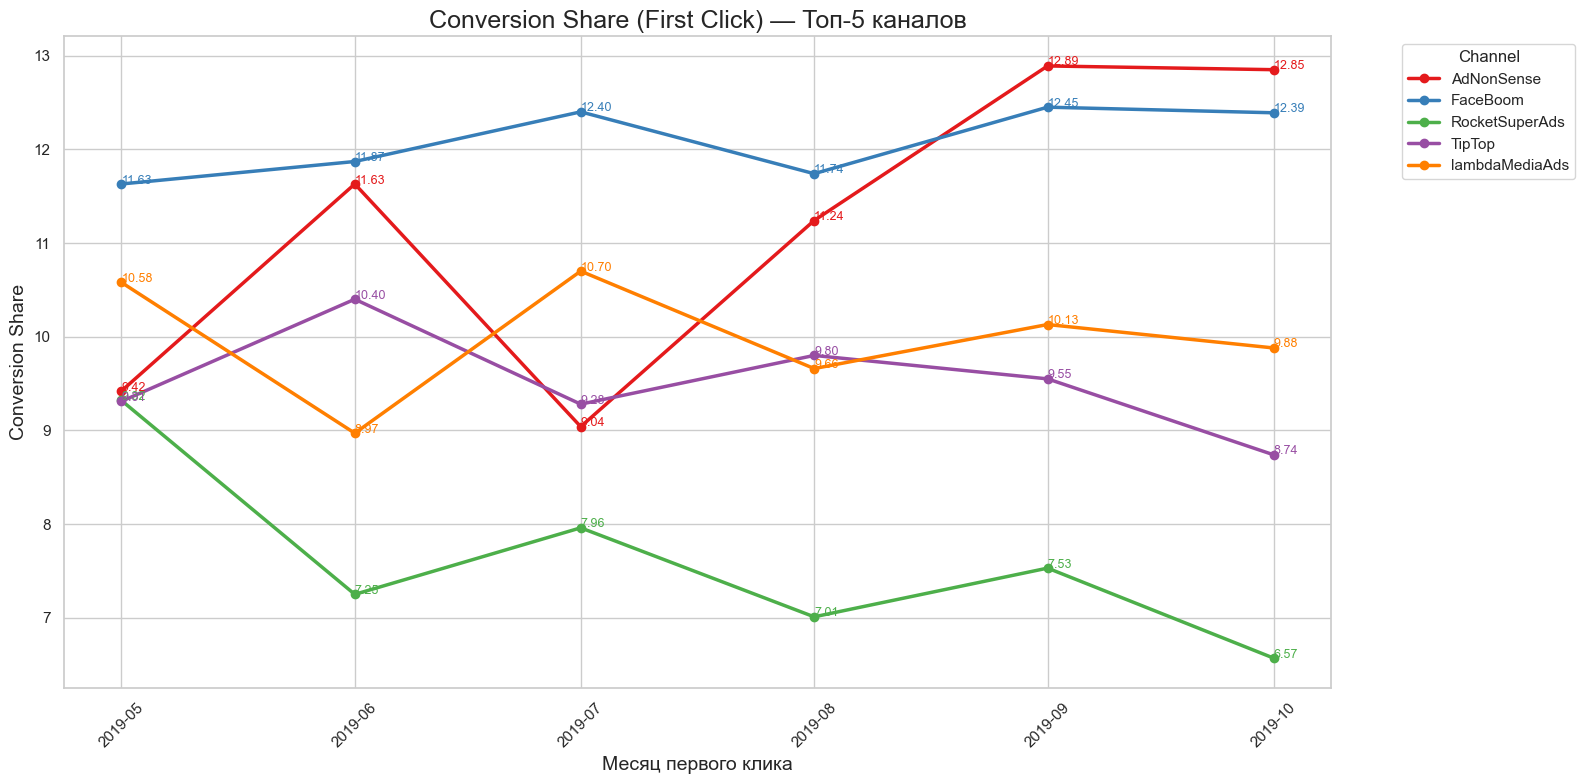

In [467]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Преобразуем колонку даты
merged['Min Session M'] = pd.to_datetime(merged['Min Session M'])

# Находим топ-5 каналов по суммарной конверсии
top_channels = (
    merged.groupby('Channel')['conversion_share_first']
    .sum()
    .nlargest(5)
    .index
)

# Фильтруем данные
filtered_df = merged[merged['Channel'].isin(top_channels)]

# Сортировка по времени (на всякий случай)
filtered_df = filtered_df.sort_values(by='Min Session M')

# Визуализация
plt.figure(figsize=(16, 8))
sns.set(style="whitegrid")

# Строим линии
palette = sns.color_palette("Set1", n_colors=len(top_channels))
for i, (channel, group) in enumerate(filtered_df.groupby('Channel')):
    plt.plot(group['Min Session M'], group['conversion_share_first'],
             label=channel, marker='o', linewidth=2.5, color=palette[i])
    
    # Добавляем подписи
    for x, y in zip(group['Min Session M'], group['conversion_share_first']):
        plt.text(x, y + 0.005, f"{y:.2f}", fontsize=9, color=palette[i])

# Настройки графика
plt.title('Conversion Share (First Click) — Топ-5 каналов', fontsize=18)
plt.xlabel('Месяц первого клика', fontsize=14)
plt.ylabel('Conversion Share', fontsize=14)
plt.xticks(rotation=45)
plt.legend(title='Channel', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()


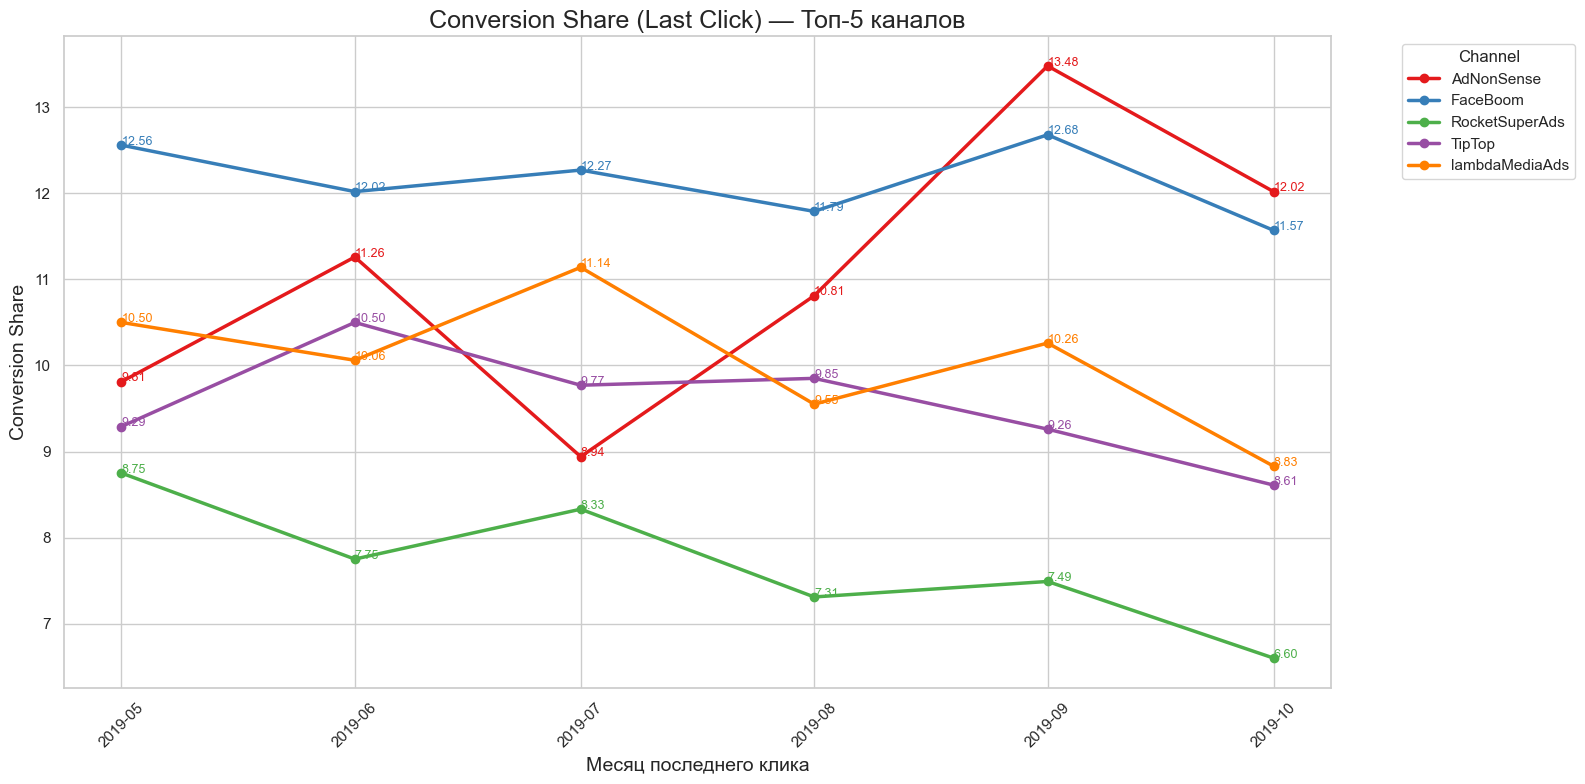

In [469]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Преобразуем колонку даты
merged['Min Session M'] = pd.to_datetime(merged['Min Session M'])

# Находим топ-5 каналов по суммарной конверсии
top_channels = (
    merged.groupby('Channel')['conversion_share_last']
    .sum()
    .nlargest(5)
    .index
)

# Фильтруем данные
filtered_df = merged[merged['Channel'].isin(top_channels)]

# Сортировка по времени (на всякий случай)
filtered_df = filtered_df.sort_values(by='Min Session M')

# Визуализация
plt.figure(figsize=(16, 8))
sns.set(style="whitegrid")

# Строим линии
palette = sns.color_palette("Set1", n_colors=len(top_channels))
for i, (channel, group) in enumerate(filtered_df.groupby('Channel')):
    plt.plot(group['Min Session M'], group['conversion_share_last'],
             label=channel, marker='o', linewidth=2.5, color=palette[i])
    
    # Добавляем подписи
    for x, y in zip(group['Min Session M'], group['conversion_share_last']):
        plt.text(x, y + 0.005, f"{y:.2f}", fontsize=9, color=palette[i])

# Настройки графика
plt.title('Conversion Share (Last Click) — Топ-5 каналов', fontsize=18)
plt.xlabel('Месяц последнего клика', fontsize=14)
plt.ylabel('Conversion Share', fontsize=14)
plt.xticks(rotation=45)
plt.legend(title='Channel', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()


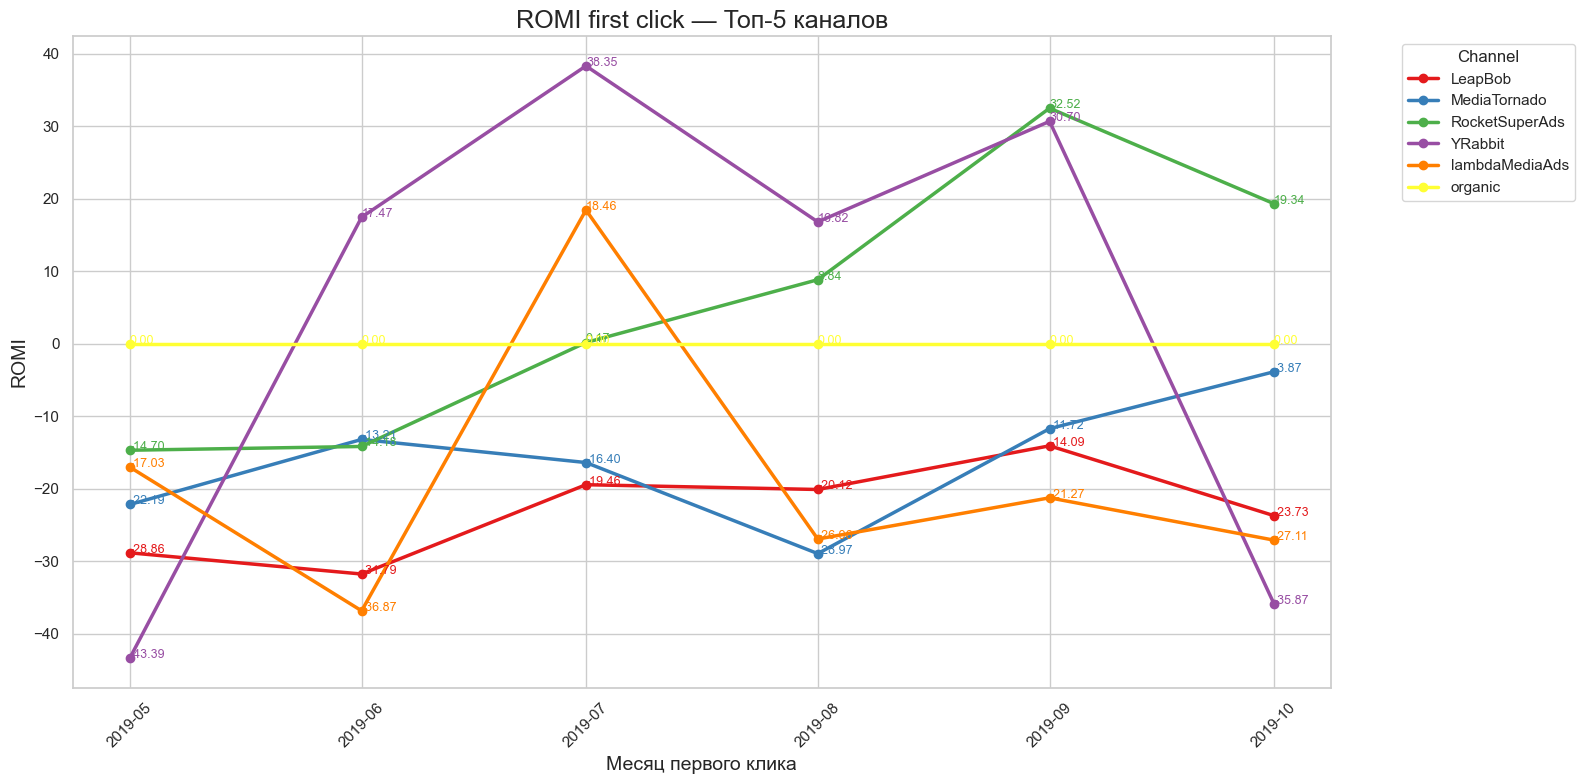

In [487]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Преобразуем колонку даты
merged['Min Session M'] = pd.to_datetime(merged['Min Session M'])

# Находим топ-5 каналов по суммарной конверсии
top_channels = (
    merged.groupby('Channel')['romi_first']
    .sum()
    .nlargest(6)
    .index
)

# Фильтруем данные
filtered_df = merged[merged['Channel'].isin(top_channels)]

# Сортировка по времени (на всякий случай)
filtered_df = filtered_df.sort_values(by='Min Session M')

# Визуализация
plt.figure(figsize=(16, 8))
sns.set(style="whitegrid")

# Строим линии
palette = sns.color_palette("Set1", n_colors=len(top_channels))
for i, (channel, group) in enumerate(filtered_df.groupby('Channel')):
    plt.plot(group['Min Session M'], group['romi_first'],
             label=channel, marker='o', linewidth=2.5, color=palette[i])
    
    # Добавляем подписи
    for x, y in zip(group['Min Session M'], group['romi_first']):
        plt.text(x, y + 0.005, f"{y:.2f}", fontsize=9, color=palette[i])

# Настройки графика
plt.title('ROMI first click — Топ-5 каналов', fontsize=18)
plt.xlabel('Месяц первого клика', fontsize=14)
plt.ylabel('ROMI %', fontsize=14)
plt.xticks(rotation=45)
plt.legend(title='Channel', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()


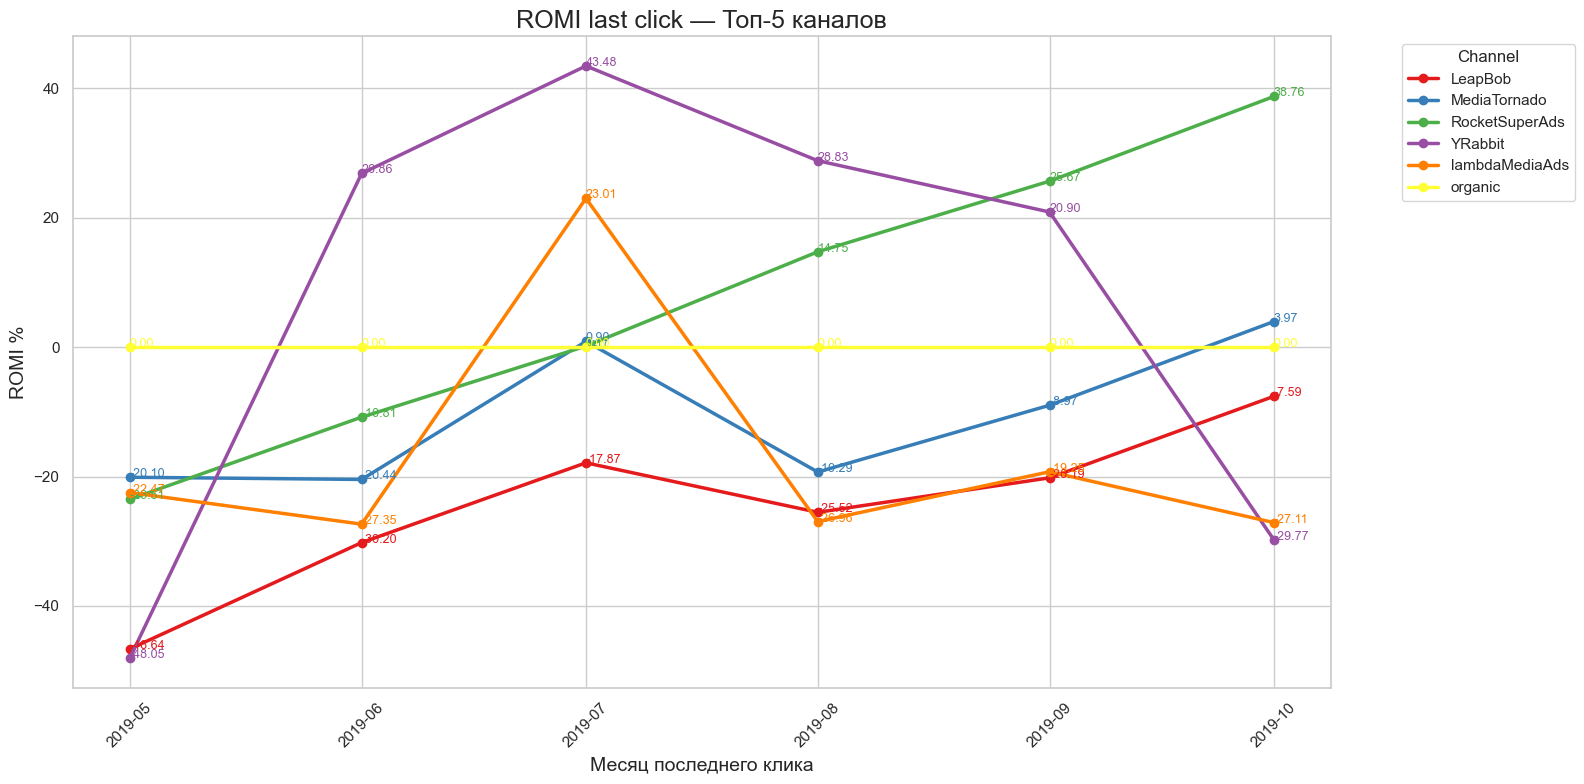

In [489]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Преобразуем колонку даты
merged['Min Session M'] = pd.to_datetime(merged['Min Session M'])

# Находим топ-5 каналов по суммарной конверсии
top_channels = (
    merged.groupby('Channel')['romi_last']
    .sum()
    .nlargest(6)
    .index
)

# Фильтруем данные
filtered_df = merged[merged['Channel'].isin(top_channels)]

# Сортировка по времени (на всякий случай)
filtered_df = filtered_df.sort_values(by='Min Session M')

# Визуализация
plt.figure(figsize=(16, 8))
sns.set(style="whitegrid")

# Строим линии
palette = sns.color_palette("Set1", n_colors=len(top_channels))
for i, (channel, group) in enumerate(filtered_df.groupby('Channel')):
    plt.plot(group['Min Session M'], group['romi_last'],
             label=channel, marker='o', linewidth=2.5, color=palette[i])
    
    # Добавляем подписи
    for x, y in zip(group['Min Session M'], group['romi_last']):
        plt.text(x, y + 0.005, f"{y:.2f}", fontsize=9, color=palette[i])

# Настройки графика
plt.title('ROMI last click — Топ-5 каналов', fontsize=18)
plt.xlabel('Месяц последнего клика', fontsize=14)
plt.ylabel('ROMI %', fontsize=14)
plt.xticks(rotation=45)
plt.legend(title='Channel', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()


## Смотрим на комбинации касаний с девайсами

In [519]:
# 1. Фильтрация визитов только с всем пользователями
visits_sorted_paid = merged_first_purchases_final[
    merged_first_purchases_final['User Id'].isin(merged_first_purchases_final['User Id'])
].sort_values(by=['User Id', 'Session Start'])

# 2. Группировка по пользователям и сбор уникальных последовательностей каналов и устройств в порядке визитов
channel_path_df_paid = visits_sorted_paid.groupby('User Id').agg({
    'Device': lambda x: ' > '.join(dict.fromkeys(x)),   # убираем повторы, сохраняем порядок
    'Channel': lambda x: ' > '.join(dict.fromkeys(x))
}).reset_index()

# 3. Вывод уникальных комбинаций Device + Channel
unique_paths = channel_path_df_paid[['Device', 'Channel']].drop_duplicates()

# Группируем по колонкам 'Device' и 'Channel' и считаем количество повторений
channel_path_counts = channel_path_df_paid.groupby(['Device', 'Channel']).size().reset_index(name='count')

# Сортируем по убыванию количества для наглядности
channel_path_counts = channel_path_counts.sort_values(by='count', ascending=False)

print(channel_path_counts.head(30)) 

      Device             Channel  count
533   iPhone             organic  19726
67   Android             organic  12627
471   iPhone            FaceBoom  12549
218      Mac             organic  10832
371       PC             organic  10752
507   iPhone              TipTop   8419
164      Mac            FaceBoom   6951
7    Android            FaceBoom   5636
194      Mac              TipTop   4568
41   Android              TipTop   3691
333       PC  OppleCreativeMedia   3351
351       PC      WahooNetBanner   3265
319       PC             LeapBob   3255
313       PC            FaceBoom   2810
13   Android             LeapBob   2459
47   Android      WahooNetBanner   2443
27   Android  OppleCreativeMedia   2405
344       PC              TipTop   1873
484   iPhone        MediaTornado   1763
497   iPhone      RocketSuperAds   1738
520   iPhone             YRabbit   1725
514   iPhone      WahooNetBanner   1612
491   iPhone  OppleCreativeMedia   1594
478   iPhone             LeapBob   1591


In [511]:
# 1. Фильтрация визитов только с теми пользователями, у кого была покупка
visits_sorted_paid = merged_first_purchases_final[
    merged_first_purchases_final['User Id'].isin(first_purchases['User Id'])
].sort_values(by=['User Id', 'Session Start'])

# 2. Группировка по пользователям и сбор уникальных последовательностей каналов и устройств в порядке визитов
channel_path_df_paid = visits_sorted_paid.groupby('User Id').agg({
    'Device': lambda x: ' > '.join(dict.fromkeys(x)),   # убираем повторы, сохраняем порядок
    'Channel': lambda x: ' > '.join(dict.fromkeys(x))
}).reset_index()

# 3. Вывод уникальных комбинаций Device + Channel
unique_paths = channel_path_df_paid[['Device', 'Channel']].drop_duplicates()

# Группируем по колонкам 'Device' и 'Channel' и считаем количество повторений
channel_path_counts = channel_path_df_paid.groupby(['Device', 'Channel']).size().reset_index(name='count')

# Сортируем по убыванию количества для наглядности
channel_path_counts = channel_path_counts.sort_values(by='count', ascending=False)

print(channel_path_counts.head(30)) 

      Device             Channel  count
177   iPhone            FaceBoom   1515
70       Mac            FaceBoom    877
196   iPhone              TipTop    783
1    Android            FaceBoom    770
85       Mac              TipTop    415
15   Android              TipTop    388
215   iPhone             organic    381
124       PC            FaceBoom    348
32   Android             organic    249
147       PC             organic    233
96       Mac             organic    219
136       PC              TipTop    191
122       PC          AdNonSense    189
138       PC      WahooNetBanner    174
190   iPhone      RocketSuperAds    151
20   Android      WahooNetBanner    137
0    Android          AdNonSense    116
126       PC             LeapBob    100
133       PC  OppleCreativeMedia     90
79       Mac      RocketSuperAds     89
171   iPhone          AdNonSense     84
144       PC      lambdaMediaAds     84
5    Android             LeapBob     82
202   iPhone      WahooNetBanner     73


In [231]:
# 1. Фильтрация визитов только с теми пользователями, у кого была покупка
visits_sorted_paid = merged_first_purchases_final[
    merged_first_purchases_final['User Id'].isin(first_purchases['User Id'])
].sort_values(by=['User Id', 'Session Start'])

# 2. Группировка по пользователям и сбор уникальных последовательностей каналов и устройств в порядке визитов
channel_path_df_paid = visits_sorted_paid.groupby('User Id').agg({
    'Device': lambda x: ' > '.join(dict.fromkeys(x)),   # убираем повторы, сохраняем порядок
    'Channel': lambda x: ' > '.join(dict.fromkeys(x))
}).reset_index()

# 3. Вывод уникальных комбинаций Device + Channel
unique_paths = channel_path_df_paid[['Device', 'Channel']].drop_duplicates()

# Группируем по колонкам 'Device' и 'Channel' и считаем количество повторений
channel_path_counts = channel_path_df_paid.groupby(['Device', 'Channel']).size().reset_index(name='count')

# Сортируем по убыванию количества для наглядности
channel_path_counts = channel_path_counts.sort_values(by='count', ascending=False)

print(channel_path_counts.head(30)) 

      Device             Channel  count
177   iPhone            FaceBoom   1515
70       Mac            FaceBoom    877
196   iPhone              TipTop    783
1    Android            FaceBoom    770
85       Mac              TipTop    415
15   Android              TipTop    388
215   iPhone             organic    381
124       PC            FaceBoom    348
32   Android             organic    249
147       PC             organic    233
96       Mac             organic    219
136       PC              TipTop    191
122       PC          AdNonSense    189
138       PC      WahooNetBanner    174
190   iPhone      RocketSuperAds    151
20   Android      WahooNetBanner    137
0    Android          AdNonSense    116
126       PC             LeapBob    100
133       PC  OppleCreativeMedia     90
79       Mac      RocketSuperAds     89
171   iPhone          AdNonSense     84
144       PC      lambdaMediaAds     84
5    Android             LeapBob     82
202   iPhone      WahooNetBanner     73


## Распрееление кол-ва касаний

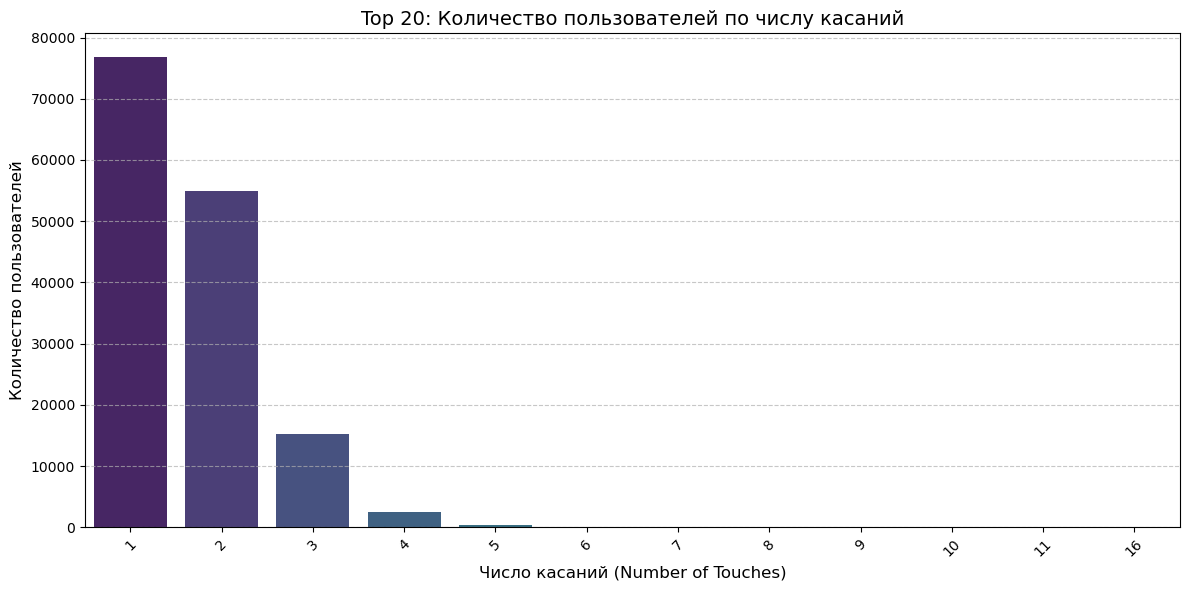

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# Считаем количество пользователей для каждого количества касаний
touch_counts = final_df['num_touches'].value_counts().sort_values(ascending=False).head(20)

# Настройка графика
plt.figure(figsize=(12, 6))
sns.barplot(x=touch_counts.index, y=touch_counts.values, palette='viridis')

# Оформление
plt.title('Top 20: Количество пользователей по числу касаний', fontsize=14)
plt.xlabel('Число касаний (Number of Touches)', fontsize=12)
plt.ylabel('Количество пользователей', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Показываем
plt.show()


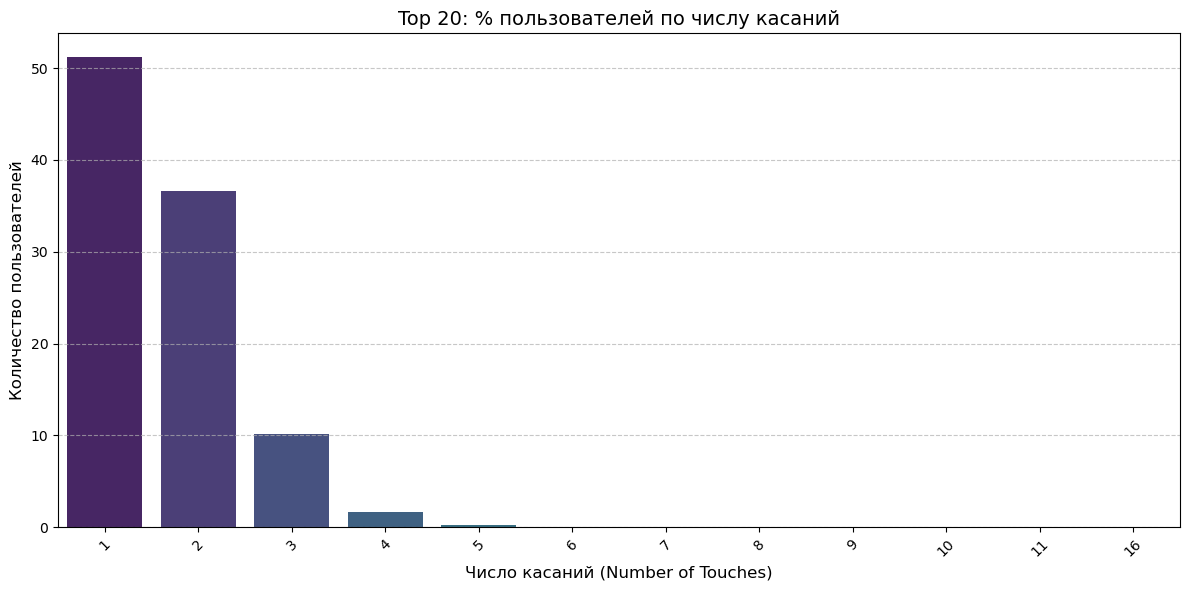

In [153]:
import matplotlib.pyplot as plt
import seaborn as sns

# Считаем количество пользователей для каждого количества касаний
touch_counts_pr = final_df['num_touches'].value_counts().sort_values(ascending=False).head(20)/150008*100

# Настройка графика
plt.figure(figsize=(12, 6))
sns.barplot(x=touch_counts_pr.index, y=touch_counts_pr.values, palette='viridis')

# Оформление
plt.title('Top 20: % пользователей по числу касаний', fontsize=14)
plt.xlabel('Число касаний (Number of Touches)', fontsize=12)
plt.ylabel('Количество пользователей', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Показываем
plt.show()

In [155]:
touch_counts_pr

num_touches
1     51.225935
2     36.590715
3     10.196123
4      1.645912
5      0.237987
6      0.059330
7      0.020666
8      0.014666
9      0.004666
11     0.002000
10     0.001333
16     0.000667
Name: count, dtype: float64

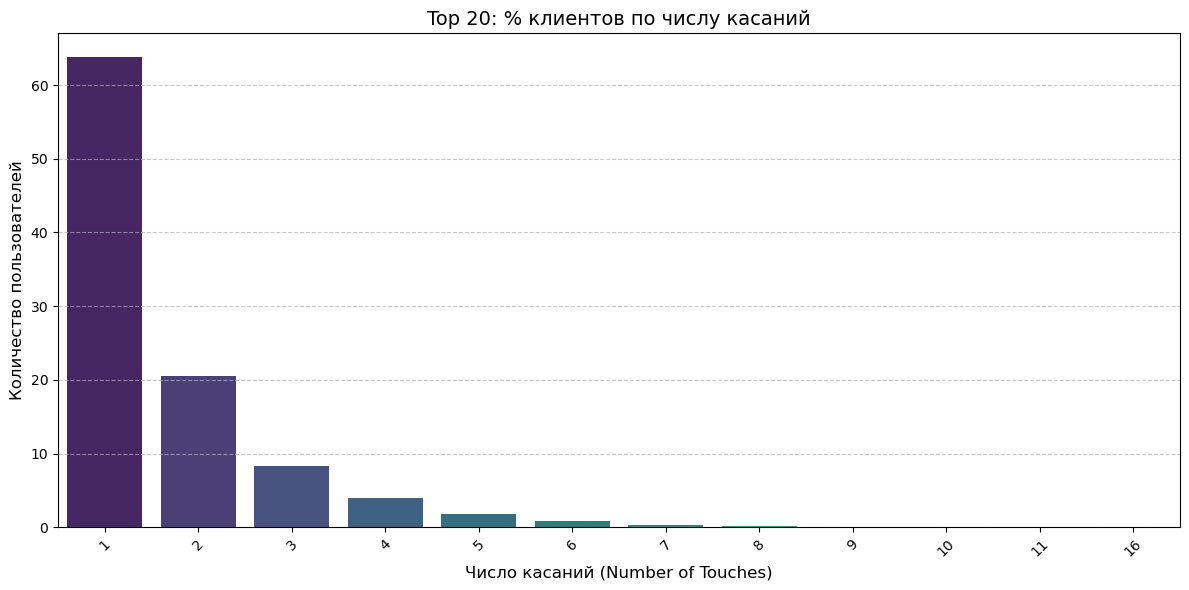

In [157]:
import matplotlib.pyplot as plt
import seaborn as sns

# Считаем количество пользователей для каждого количества касаний
touch_counts_pr = final_df['num_touches'][final_df['is_paid']==True].value_counts().sort_values(ascending=False).head(20)/8881*100

# Настройка графика
plt.figure(figsize=(12, 6))
sns.barplot(x=touch_counts_pr.index, y=touch_counts_pr.values, palette='viridis')

# Оформление
plt.title('Top 20: % клиентов по числу касаний', fontsize=14)
plt.xlabel('Число касаний (Number of Touches)', fontsize=12)
plt.ylabel('Количество пользователей', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Показываем
plt.show()

In [159]:
touch_counts_pr

num_touches
1     63.832902
2     20.526968
3      8.343655
4      3.940998
5      1.734039
6      0.889539
7      0.349060
8      0.236460
9      0.078820
11     0.033780
10     0.022520
16     0.011260
Name: count, dtype: float64

## Модель графов

In [74]:
final_df_paid = final_df[final_df['is_paid']==True]

graf_df=final_df_paid[final_df_paid['is_paid']==True]
graf_df['touch_path']= graf_df['touch_path'].apply(lambda x:  'Start > '+x)

In [89]:
graf_df

,User Id,touch_path,num_touches,Min_Channel,is_paid,live_time_hours,channels
0,599326,Start > FaceBoom 1 > Conversion,1,FaceBoom,True,0.0,"[Start, FaceBoom 1, Conversion]"
7,46006712,Start > AdNonSense 1 > Conversion,1,AdNonSense,True,0.0,"[Start, AdNonSense 1, Conversion]"
61,374052872,Start > TipTop 1 > TipTop 2 > Conversion,2,TipTop,True,184.0,"[Start, TipTop 1, TipTop 2, Conversion]"
71,414791703,Start > TipTop 1 > TipTop 2 > Conversion,2,TipTop,True,30.1,"[Start, TipTop 1, TipTop 2, Conversion]"
124,785077127,Start > TipTop 1 > TipTop 2 > TipTop 3 > Conve...,3,TipTop,True,82.1,"[Start, TipTop 1, TipTop 2, TipTop 3, Conversion]"
...,...,...,...,...,...,...,...
149936,999625937544,Start > YRabbit 1 > Conversion,1,YRabbit,True,0.0,"[Start, YRabbit 1, Conversion]"
149943,999645428220,Start > TipTop 1 > Conversion,1,TipTop,True,0.0,"[Start, TipTop 1, Conversion]"
149946,999659859721,Start > organic 1 > organic 2 > organic 3 > Co...,3,organic,True,86.9,"[Start, organic 1, organic 2, organic 3, Conve..."
149972,999779032958,Start > TipTop 1 > TipTop 2 > Conversion,2,TipTop,True,36.5,"[Start, TipTop 1, TipTop 2, Conversion]"


In [79]:
graf_df['channels'] = graf_df['touch_path'].str.split(' > ')

In [115]:
from pyvis.network import Network
from collections import defaultdict, Counter
import random
import networkx as nx
# Каналы привлечения
channels = merged_first_purchases_final['Channel Numbered'].unique().tolist()

colors = {
    'FaceBoom 1': '#4a90e2',        # яркий синий
    'organic 1': '#50e3c2',         # мятный
    'MediaTornado 1': '#7ed6df',    # светлый бирюзовый
    'RocketSuperAds 1': '#44bd32',  # лаймово-зелёный
    'TipTop 1': '#f5a623',          # янтарно-жёлтый
    'YRabbit 1': '#9b59b6',         # аметистовый
    'AdNonSense 1': '#16a085',      # изумрудный
    'lambdaMediaAds 1': '#f39c12',  # солнечный оранжевый
    'OppleCreativeMedia 1': '#8e44ad', # сливовый
    'WahooNetBanner 1': '#2980b9',   # насыщенный синий
    'FaceBoom 2': '#4a90e2',        # яркий синий
    'organic 2': '#50e3c2',         # мятный
    'MediaTornado 2': '#7ed6df',    # светлый бирюзовый
    'RocketSuperAds 2': '#44bd32',  # лаймово-зелёный
    'TipTop 2': '#f5a623',          # янтарно-жёлтый
    'YRabbit 2': '#9b59b6',         # аметистовый
    'AdNonSense 2': '#16a085',      # изумрудный
    'lambdaMediaAds 2': '#f39c12',  # солнечный оранжевый
    'OppleCreativeMedia 2': '#8e44ad', # сливовый
    'WahooNetBanner 2': '#2980b9',   # насыщенный синий
    'FaceBoom 3': '#4a90e2',        # яркий синий
    'organic 3': '#50e3c2',         # мятный
    'MediaTornado 3': '#7ed6df',    # светлый бирюзовый
    'RocketSuperAds 3': '#44bd32',  # лаймово-зелёный
    'TipTop 3': '#f5a623',          # янтарно-жёлтый
    'YRabbit 3': '#9b59b6',         # аметистовый
    'AdNonSense 3': '#16a085',      # изумрудный
    'lambdaMediaAds 3': '#f39c12',  # солнечный оранжевый
    'OppleCreativeMedia 3': '#8e44ad', # сливовый
    'WahooNetBanner 3': '#2980b9',  # насыщенный синий
    'TipTop 4': '#f5a623',          
    'Start': '#4a21b0',           # графитово-серый
    'Conversion': '#4a21b0'       # яркий золотой
}

paths=list(graf_df.channels.apply(lambda x:  tuple(x)))
path_counts = Counter(paths)
top_20_paths = path_counts.most_common(15)

In [117]:
top_20_paths

[(('Start', 'FaceBoom 1', 'Conversion'), 2875),
 (('Start', 'TipTop 1', 'Conversion'), 955),
 (('Start', 'organic 1', 'Conversion'), 574),
 (('Start', 'FaceBoom 1', 'FaceBoom 2', 'Conversion'), 521),
 (('Start', 'TipTop 1', 'TipTop 2', 'Conversion'), 455),
 (('Start', 'AdNonSense 1', 'Conversion'), 325),
 (('Start', 'organic 1', 'organic 2', 'Conversion'), 278),
 (('Start', 'WahooNetBanner 1', 'Conversion'), 230),
 (('Start', 'TipTop 1', 'TipTop 2', 'TipTop 3', 'Conversion'), 217),
 (('Start', 'OppleCreativeMedia 1', 'Conversion'), 141),
 (('Start', 'organic 1', 'organic 2', 'organic 3', 'Conversion'), 130),
 (('Start', 'LeapBob 1', 'Conversion'), 126),
 (('Start', 'lambdaMediaAds 1', 'Conversion'), 125),
 (('Start', 'FaceBoom 1', 'FaceBoom 2', 'FaceBoom 3', 'Conversion'), 123),
 (('Start', 'RocketSuperAds 1', 'Conversion'), 119)]

In [119]:
# Собираем рёбра и веса
edge_weights = defaultdict(int)
nodes_set = set()
for path, count in top_20_paths:
    for i in range(len(path) - 1):
        edge_weights[(path[i], path[i + 1])] += count
        nodes_set.add(path[i])
        nodes_set.add(path[i + 1])

In [121]:
from pyvis.network import Network
import numpy as np

# Нормализация весов для ширины рёбер (чем больше weight, тем толще линия)
max_weight = max(edge_weights.values())
min_weight = min(edge_weights.values())
weight_range = max_weight - min_weight if max_weight != min_weight else 1

def get_width(weight):
    # Нормализация от 1 до 10, можно подстроить масштаб под свои данные
    return 1 + 9 * (weight - min_weight) / weight_range

# Создание сети
net = Network(height='1800px', width='1800px', bgcolor='#ffffff', font_color='black')

# Добавляем узлы
for node in nodes_set:
    net.add_node(
        node,
        label=node,
        color=colors.get(node, '#cccccc'),
        physics=False,
        fixed=False
    )

# Добавляем рёбра с шириной в зависимости от веса
for (src, dst), weight in edge_weights.items():
    net.add_edge(
        src, dst,
        value=weight,
        title=f'{weight} переходов',
        label=str(weight),
        width=get_width(weight)
    )

# Настройка физики и стиля
net.set_options("""
var options = {
  "nodes": {
    "shape": "dot",
    "size": 25,
    "font": {
      "size": 25,
      "face": "Tahoma"
    }
  },
  "edges": {
    "smooth": {
      "type": "cubicBezier",
      "forceDirection": "horizontal",
      "roundness": 0.4
    },
    "arrows": {
      "to": {
        "enabled": true,
        "scaleFactor": 0.5
      }
    },
    "font": {
      "size": 60,
      "align": "middle"
    }
  },
  "physics": {
    "enabled": true,
    "barnesHut": {
      "gravitationalConstant": -4000,
      "springLength": 200,
      "springConstant": 0.04,
      "damping": 0.08,
      "avoidOverlap": 1
    }
  }
}
""")

# Рендерим граф
net.show('realistic_marketing_paths_true_final.html', notebook=False)


realistic_marketing_paths_true_final.html


In [129]:
final_df_paid_2 = final_df[final_df['is_paid']==False]
graf_df_not_paid=final_df_paid_2[final_df_paid_2['is_paid']==False]
graf_df_not_paid['touch_path']= graf_df_not_paid['touch_path'].apply(lambda x:  'Start > '+x)

In [135]:
graf_df_not_paid

,User Id,touch_path,num_touches,Min_Channel,is_paid,live_time_hours,channels
1,4919697,Start > FaceBoom 1 > FaceBoom 2,2,FaceBoom,False,33.7,"[Start, FaceBoom 1, FaceBoom 2]"
2,6085896,Start > organic 1 > organic 2,2,organic,False,48.2,"[Start, organic 1, organic 2]"
3,22593348,Start > AdNonSense 1,1,AdNonSense,False,0.0,"[Start, AdNonSense 1]"
4,31989216,Start > YRabbit 1,1,YRabbit,False,0.0,"[Start, YRabbit 1]"
5,34186288,Start > organic 1 > organic 2,2,organic,False,8.7,"[Start, organic 1, organic 2]"
...,...,...,...,...,...,...,...
150003,999956196527,Start > TipTop 1 > TipTop 2,2,TipTop,False,22.4,"[Start, TipTop 1, TipTop 2]"
150004,999975439887,Start > organic 1 > organic 2,2,organic,False,146.6,"[Start, organic 1, organic 2]"
150005,999976332130,Start > TipTop 1,1,TipTop,False,0.0,"[Start, TipTop 1]"
150006,999979924135,Start > MediaTornado 1 > MediaTornado 2,2,MediaTornado,False,130.1,"[Start, MediaTornado 1, MediaTornado 2]"


In [133]:
graf_df_not_paid['channels'] = graf_df_not_paid['touch_path'].str.split(' > ')

In [137]:
from pyvis.network import Network
from collections import defaultdict, Counter
import random
import networkx as nx
# Каналы привлечения
channels = merged_first_purchases_final['Channel Numbered'].unique().tolist()

colors = {
    'FaceBoom 1': '#4a90e2',        # яркий синий
    'organic 1': '#50e3c2',         # мятный
    'MediaTornado 1': '#7ed6df',    # светлый бирюзовый
    'RocketSuperAds 1': '#44bd32',  # лаймово-зелёный
    'TipTop 1': '#f5a623',          # янтарно-жёлтый
    'YRabbit 1': '#9b59b6',         # аметистовый
    'AdNonSense 1': '#16a085',      # изумрудный
    'lambdaMediaAds 1': '#f39c12',  # солнечный оранжевый
    'OppleCreativeMedia 1': '#8e44ad', # сливовый
    'WahooNetBanner 1': '#2980b9',   # насыщенный синий
    'FaceBoom 2': '#4a90e2',        # яркий синий
    'organic 2': '#50e3c2',         # мятный
    'MediaTornado 2': '#7ed6df',    # светлый бирюзовый
    'RocketSuperAds 2': '#44bd32',  # лаймово-зелёный
    'TipTop 2': '#f5a623',          # янтарно-жёлтый
    'YRabbit 2': '#9b59b6',         # аметистовый
    'AdNonSense 2': '#16a085',      # изумрудный
    'lambdaMediaAds 2': '#f39c12',  # солнечный оранжевый
    'OppleCreativeMedia 2': '#8e44ad', # сливовый
    'WahooNetBanner 2': '#2980b9',   # насыщенный синий
    'FaceBoom 3': '#4a90e2',        # яркий синий
    'organic 3': '#50e3c2',         # мятный
    'MediaTornado 3': '#7ed6df',    # светлый бирюзовый
    'RocketSuperAds 3': '#44bd32',  # лаймово-зелёный
    'TipTop 3': '#f5a623',          # янтарно-жёлтый
    'YRabbit 3': '#9b59b6',         # аметистовый
    'AdNonSense 3': '#16a085',      # изумрудный
    'lambdaMediaAds 3': '#f39c12',  # солнечный оранжевый
    'OppleCreativeMedia 3': '#8e44ad', # сливовый
    'WahooNetBanner 3': '#2980b9',  # насыщенный синий
    'TipTop 4': '#f5a623',          
    'Start': '#4a21b0',           # графитово-серый
    'Conversion': '#4a21b0'       # яркий золотой
}

paths=list(graf_df_not_paid.channels.apply(lambda x:  tuple(x)))
path_counts = Counter(paths)
top_20_paths = path_counts.most_common(15)

In [139]:
top_20_paths

[(('Start', 'organic 1'), 27777),
 (('Start', 'organic 1', 'organic 2'), 20164),
 (('Start', 'FaceBoom 1'), 12918),
 (('Start', 'FaceBoom 1', 'FaceBoom 2'), 9296),
 (('Start', 'TipTop 1'), 8913),
 (('Start', 'TipTop 1', 'TipTop 2'), 6326),
 (('Start', 'organic 1', 'organic 2', 'organic 3'), 5418),
 (('Start', 'OppleCreativeMedia 1'), 4267),
 (('Start', 'LeapBob 1'), 4220),
 (('Start', 'WahooNetBanner 1'), 4053),
 (('Start', 'LeapBob 1', 'LeapBob 2'), 2944),
 (('Start', 'WahooNetBanner 1', 'WahooNetBanner 2'), 2937),
 (('Start', 'OppleCreativeMedia 1', 'OppleCreativeMedia 2'), 2921),
 (('Start', 'FaceBoom 1', 'FaceBoom 2', 'FaceBoom 3'), 2435),
 (('Start', 'MediaTornado 1'), 2139)]

In [143]:
# Собираем рёбра и веса
edge_weights = defaultdict(int)
nodes_set = set()
for path, count in top_20_paths:
    for i in range(len(path) - 1):
        edge_weights[(path[i], path[i + 1])] += count
        nodes_set.add(path[i])
        nodes_set.add(path[i + 1])

In [145]:
from pyvis.network import Network
import numpy as np

# Нормализация весов для ширины рёбер (чем больше weight, тем толще линия)
max_weight = max(edge_weights.values())
min_weight = min(edge_weights.values())
weight_range = max_weight - min_weight if max_weight != min_weight else 1

def get_width(weight):
    # Нормализация от 1 до 10, можно подстроить масштаб под свои данные
    return 1 + 9 * (weight - min_weight) / weight_range

# Создание сети
net = Network(height='1800px', width='1800px', bgcolor='#ffffff', font_color='black')

# Добавляем узлы
for node in nodes_set:
    net.add_node(
        node,
        label=node,
        color=colors.get(node, '#cccccc'),
        physics=False,
        fixed=False
    )

# Добавляем рёбра с шириной в зависимости от веса
for (src, dst), weight in edge_weights.items():
    net.add_edge(
        src, dst,
        value=weight,
        title=f'{weight} переходов',
        label=str(weight),
        width=get_width(weight)
    )

# Настройка физики и стиля
net.set_options("""
var options = {
  "nodes": {
    "shape": "dot",
    "size": 25,
    "font": {
      "size": 25,
      "face": "Tahoma"
    }
  },
  "edges": {
    "smooth": {
      "type": "cubicBezier",
      "forceDirection": "horizontal",
      "roundness": 0.4
    },
    "arrows": {
      "to": {
        "enabled": true,
        "scaleFactor": 0.5
      }
    },
    "font": {
      "size": 60,
      "align": "middle"
    }
  },
  "physics": {
    "enabled": true,
    "barnesHut": {
      "gravitationalConstant": -4000,
      "springLength": 200,
      "springConstant": 0.04,
      "damping": 0.08,
      "avoidOverlap": 1
    }
  }
}
""")

# Рендерим граф
net.show('realistic_marketing_paths_false_final.html', notebook=False)


realistic_marketing_paths_false_final.html
